In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import seaborn as sns


In [2]:
df = pd.read_csv("../Data/wildfires_sample_100k.csv", low_memory=False)

In [3]:
wildfires = (
    df[["FIRE_YEAR", "DISCOVERY_DOY", "FIRE_SIZE", "LATITUDE", "LONGITUDE", "STATE"]]
    .copy()
)

wildfires["STATE"] = wildfires["STATE"].astype("category")

In [4]:
fires = wildfires.copy()

fires["FIRE_DATE"] = pd.to_datetime(
    fires["FIRE_YEAR"].astype(str) + "-" + fires["DISCOVERY_DOY"].astype(str),
    format="%Y-%j"
)

fires["YEAR"] = fires["FIRE_DATE"].dt.year
fires["MONTH"] = fires["FIRE_DATE"].dt.month


In [44]:
notable_threshold_acres = 300

# Filter notable fires
notable_fires = fires[fires["FIRE_SIZE"] >= notable_threshold_acres]

print("Number of notable fires:", notable_fires.shape[0])

Number of notable fires: 1381


In [81]:

# ---- Create grid IDs and month index ----
notable_fires = notable_fires.copy()

notable_fires["lat_bin"] = np.floor(notable_fires["LATITUDE"]).astype(int)
notable_fires["lon_bin"] = np.floor(notable_fires["LONGITUDE"]).astype(int)
notable_fires["ym"] = notable_fires["YEAR"] * 100 + notable_fires["MONTH"]

# Fire indicator at (grid, month): did any notable fire occur?
grid_month_fire = (
    notable_fires
    .groupby(["lat_bin", "lon_bin", "ym"], as_index=False)
    .size()
    .rename(columns={"size": "n_fires"})
)

grid_month_fire["fire_this_month"] = 1

grid_month_fire.head()
# ym in YYYYMM form 

,lat_bin,lon_bin,ym,n_fires,fire_this_month
0,17,-67,200407,1,1
1,18,-68,200906,1,1
2,18,-67,200503,1,1
3,19,-156,199210,1,1
4,19,-156,199910,1,1


In [71]:
# ---- Build panel (all grid cells that appear at least once) ----
all_grids = grid_month_fire[["lat_bin", "lon_bin"]].drop_duplicates().copy()

# Generate a safe monthly sequence using actual dates
min_ym = grid_month_fire["ym"].min()
max_ym = grid_month_fire["ym"].max()

start_date = pd.Timestamp(year=min_ym // 100, month=min_ym % 100, day=1)  
end_date   = pd.Timestamp(year=max_ym // 100, month=max_ym % 100, day=1)

all_months = pd.DataFrame({
    "date": pd.date_range(start=start_date, end=end_date, freq="MS")
})

all_months["year"] = all_months["date"].dt.year
all_months["month"] = all_months["date"].dt.month
all_months["ym"] = all_months["year"] * 100 + all_months["month"]
all_months = all_months[["ym", "year", "month"]]

# Full panel = grid × month
panel_1= (
    all_grids.merge(all_months, how="cross")
    .merge(
        grid_month_fire[["lat_bin", "lon_bin", "ym", "fire_this_month"]],
        on=["lat_bin", "lon_bin", "ym"],
        how="left"
    )
)

panel_1["fire_this_month"] = panel_1["fire_this_month"].fillna(0).astype(int)
panel_1

#print(start_date)
#print(end_date)  
# from 1992-01 to 2015-11

,lat_bin,lon_bin,ym,year,month,fire_this_month
0,17,-67,199201,1992,1,0
1,17,-67,199202,1992,2,0
2,17,-67,199203,1992,3,0
3,17,-67,199204,1992,4,0
4,17,-67,199205,1992,5,0
...,...,...,...,...,...,...
148087,69,-157,201507,2015,7,0
148088,69,-157,201508,2015,8,0
148089,69,-157,201509,2015,9,0
148090,69,-157,201510,2015,10,0


In [97]:
# Sort so lead works correctly
panel_ref=panel_1.copy()
panel_2 = panel_1.sort_values(["lat_bin", "lon_bin", "ym"])
# Compute next-month fire indicator
panel_2["y_next"] = (
    panel_ref.groupby(["lat_bin", "lon_bin"])["fire_this_month"]
    .shift(-1)
)
# Remove last observation of each grid (no next month available)
panel_2= panel_2.dropna(subset=["y_next"])
# convert to integer
panel_2["y_next"] = panel_2["y_next"].astype(int)
# distribution of the outcome
print(panel_2["y_next"].value_counts())
panel=panel_2.copy()
panel

y_next
0    146265
1      1311
Name: count, dtype: int64


,lat_bin,lon_bin,ym,year,month,fire_this_month,y_next
0,17,-67,199201,1992,1,0,0
1,17,-67,199202,1992,2,0,0
2,17,-67,199203,1992,3,0,0
3,17,-67,199204,1992,4,0,0
4,17,-67,199205,1992,5,0,0
...,...,...,...,...,...,...,...
148086,69,-157,201506,2015,6,0,0
148087,69,-157,201507,2015,7,0,0
148088,69,-157,201508,2015,8,0,0
148089,69,-157,201509,2015,9,0,0


In [82]:
notable_fires

,FIRE_YEAR,DISCOVERY_DOY,FIRE_SIZE,LATITUDE,LONGITUDE,STATE,FIRE_DATE,YEAR,MONTH,lat_bin,lon_bin,ym
26,2005,197,1300.0,33.933611,-111.379722,AZ,2005-07-16,2005,7,33,-112,200507
27,2005,198,495.0,33.862500,-111.155833,AZ,2005-07-17,2005,7,33,-112,200507
31,2005,219,800.0,48.834167,-115.185000,MT,2005-08-07,2005,8,48,-116,200508
184,2005,217,817.0,45.976667,-114.960000,ID,2005-08-05,2005,8,45,-115,200508
186,2005,224,600.0,45.748333,-115.165000,ID,2005-08-12,2005,8,45,-116,200508
...,...,...,...,...,...,...,...,...,...,...,...,...
98995,1992,212,300.0,21.497620,-158.187042,HI,1992-07-30,1992,7,21,-159,199207
99381,1999,280,5000.0,19.830477,-155.927155,HI,1999-10-07,1999,10,19,-156,199910
99384,2005,214,2500.0,20.142124,-155.887528,HI,2005-08-02,2005,8,20,-156,200508
99396,2010,65,600.0,19.924816,-155.786957,HI,2010-03-06,2010,3,19,-156,201003


In [98]:
def mode_state(x):
    return x.value_counts().idxmax()

grid_state = (
    notable_fires
    .groupby(["lat_bin", "lon_bin"])["STATE"]
    .apply(mode_state)
    .reset_index()
    .rename(columns={"STATE": "state"})
)
# Merge grid to a signle state


panel = panel.merge(
    grid_state,
    on=["lat_bin", "lon_bin"],
    how="left"
)

panel # Acatual full panel. 

,lat_bin,lon_bin,ym,year,month,fire_this_month,y_next,state
0,17,-67,199201,1992,1,0,0,PR
1,17,-67,199202,1992,2,0,0,PR
2,17,-67,199203,1992,3,0,0,PR
3,17,-67,199204,1992,4,0,0,PR
4,17,-67,199205,1992,5,0,0,PR
...,...,...,...,...,...,...,...,...
147571,69,-157,201506,2015,6,0,0,AK
147572,69,-157,201507,2015,7,0,0,AK
147573,69,-157,201508,2015,8,0,0,AK
147574,69,-157,201509,2015,9,0,0,AK


In [99]:
panel["month_sin"] = np.sin(2 * np.pi * panel["month"] / 12)
panel["month_cos"] = np.cos(2 * np.pi * panel["month"] / 12)
#panel[["month_sin", "month_cos"]].head()
panel

,lat_bin,lon_bin,ym,year,month,fire_this_month,y_next,state,month_sin,month_cos
0,17,-67,199201,1992,1,0,0,PR,5.000000e-01,8.660254e-01
1,17,-67,199202,1992,2,0,0,PR,8.660254e-01,5.000000e-01
2,17,-67,199203,1992,3,0,0,PR,1.000000e+00,6.123234e-17
3,17,-67,199204,1992,4,0,0,PR,8.660254e-01,-5.000000e-01
4,17,-67,199205,1992,5,0,0,PR,5.000000e-01,-8.660254e-01
...,...,...,...,...,...,...,...,...,...,...
147571,69,-157,201506,2015,6,0,0,AK,1.224647e-16,-1.000000e+00
147572,69,-157,201507,2015,7,0,0,AK,-5.000000e-01,-8.660254e-01
147573,69,-157,201508,2015,8,0,0,AK,-8.660254e-01,-5.000000e-01
147574,69,-157,201509,2015,9,0,0,AK,-1.000000e+00,-1.836970e-16


In [100]:
grid_fire_size = (
    notable_fires
    .groupby(["lat_bin", "lon_bin", "ym"], as_index=False)
    .agg(
        n_fires=("FIRE_SIZE", "size"),
        fire_size=("FIRE_SIZE", "mean")
    )
)
#grid_fire_size

In [102]:
panel = panel.merge(
    grid_fire_size,
    on=["lat_bin", "lon_bin", "ym"],
    how="left"
)
panel

,lat_bin,lon_bin,ym,year,month,fire_this_month,y_next,state,month_sin,month_cos,n_fires,fire_size
0,17,-67,199201,1992,1,0,0,PR,5.000000e-01,8.660254e-01,NaN,NaN
1,17,-67,199202,1992,2,0,0,PR,8.660254e-01,5.000000e-01,NaN,NaN
2,17,-67,199203,1992,3,0,0,PR,1.000000e+00,6.123234e-17,NaN,NaN
3,17,-67,199204,1992,4,0,0,PR,8.660254e-01,-5.000000e-01,NaN,NaN
4,17,-67,199205,1992,5,0,0,PR,5.000000e-01,-8.660254e-01,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
147571,69,-157,201506,2015,6,0,0,AK,1.224647e-16,-1.000000e+00,NaN,NaN
147572,69,-157,201507,2015,7,0,0,AK,-5.000000e-01,-8.660254e-01,NaN,NaN
147573,69,-157,201508,2015,8,0,0,AK,-8.660254e-01,-5.000000e-01,NaN,NaN
147574,69,-157,201509,2015,9,0,0,AK,-1.000000e+00,-1.836970e-16,NaN,NaN


In [104]:
panel["fire_size"] = panel["fire_size"].fillna(0)
panel["n_fires"] = panel["n_fires"].fillna(0).astype(int)

panel = panel.sort_values(["lat_bin", "lon_bin", "ym"]).copy()

In [105]:
panel

,lat_bin,lon_bin,ym,year,month,fire_this_month,y_next,state,month_sin,month_cos,n_fires,fire_size
0,17,-67,199201,1992,1,0,0,PR,5.000000e-01,8.660254e-01,0,0.0
1,17,-67,199202,1992,2,0,0,PR,8.660254e-01,5.000000e-01,0,0.0
2,17,-67,199203,1992,3,0,0,PR,1.000000e+00,6.123234e-17,0,0.0
3,17,-67,199204,1992,4,0,0,PR,8.660254e-01,-5.000000e-01,0,0.0
4,17,-67,199205,1992,5,0,0,PR,5.000000e-01,-8.660254e-01,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
147571,69,-157,201506,2015,6,0,0,AK,1.224647e-16,-1.000000e+00,0,0.0
147572,69,-157,201507,2015,7,0,0,AK,-5.000000e-01,-8.660254e-01,0,0.0
147573,69,-157,201508,2015,8,0,0,AK,-8.660254e-01,-5.000000e-01,0,0.0
147574,69,-157,201509,2015,9,0,0,AK,-1.000000e+00,-1.836970e-16,0,0.0


In [106]:
g = panel.groupby(["lat_bin", "lon_bin"])
g

In [107]:
# lagged fire indicator/count history
panel["fire_lag12"] = g["fire_this_month"].shift(12)

# rolling fire counts based on previous months only
panel["fire_roll3"] = (
    g["fire_this_month"]
    .transform(lambda s: s.shift(1).rolling(window=3, min_periods=1).sum())
)

panel["fire_roll12"] = (
    g["fire_this_month"]
    .transform(lambda s: s.shift(1).rolling(window=12, min_periods=1).sum())
)

# rolling burn area / avg fire size using previous months only
panel["size_roll3"] = (
    g["fire_size"]
    .transform(lambda s: s.shift(1).rolling(window=3, min_periods=1).mean())
)

panel["size_roll12"] = (
    g["fire_size"]
    .transform(lambda s: s.shift(1).rolling(window=12, min_periods=1).mean())
)

In [111]:
panel[[
    "n_fires", "fire_lag12", "fire_roll3", "fire_roll12", "size_roll3", "size_roll12"
]].describe()

,n_fires,fire_lag12,fire_roll3,fire_roll12,size_roll3,size_roll12
count,147576.000000,141384.000000,147060.00000,147060.000000,147060.000000,147060.000000
mean,0.009351,0.008898,0.02654,0.103903,43.186834,41.449179
std,0.101391,0.093908,0.16753,0.339283,1051.629213,516.163951
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
max,3.000000,1.000000,3.00000,4.000000,114944.333333,28736.083333


In [78]:
model_df = (
    panel.assign(
        y_next = panel["y_next"].astype("category")
    )[[
        "y_next",
        "lat_bin", "lon_bin", "state",
        "month_cos", "month_sin", "year",
        "n_fires", "fire_lag12", "fire_roll3", "fire_roll12",
        "size_roll3", "size_roll12"
    ]]
)

model_df

,y_next,lat_bin,lon_bin,state,month_cos,month_sin,year,n_fires,fire_lag12,fire_roll3,fire_roll12,size_roll3,size_roll12
0,0,17,-67,PR,8.660254e-01,5.000000e-01,1992,0,NaN,NaN,NaN,NaN,NaN
1,0,17,-67,PR,5.000000e-01,8.660254e-01,1992,0,NaN,0.0,0.0,0.0,0.0
2,0,17,-67,PR,6.123234e-17,1.000000e+00,1992,0,NaN,0.0,0.0,0.0,0.0
3,0,17,-67,PR,-5.000000e-01,8.660254e-01,1992,0,NaN,0.0,0.0,0.0,0.0
4,0,17,-67,PR,-8.660254e-01,5.000000e-01,1992,0,NaN,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
147571,0,69,-157,AK,-1.000000e+00,1.224647e-16,2015,0,0.0,0.0,0.0,0.0,0.0
147572,0,69,-157,AK,-8.660254e-01,-5.000000e-01,2015,0,0.0,0.0,0.0,0.0,0.0
147573,0,69,-157,AK,-5.000000e-01,-8.660254e-01,2015,0,0.0,0.0,0.0,0.0,0.0
147574,0,69,-157,AK,-1.836970e-16,-1.000000e+00,2015,0,0.0,0.0,0.0,0.0,0.0


In [75]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# make sure target is numeric 0/1
model_df_cv = model_df.copy()
model_df_cv["y_next"] = model_df_cv["y_next"].astype(int)

years_sorted = np.sort(model_df_cv["year"].unique())
min_train_years = 3

results = []

feature_cols = [
    "lat_bin", "lon_bin", "state",
    "month_cos", "month_sin", "year",
    "n_fires", "fire_lag12", "fire_roll3", "fire_roll12",
    "size_roll3", "size_roll12"
]

categorical_features = ["state"]
numeric_features = [
    "lat_bin", "lon_bin",
    "month_cos", "month_sin", "year",
    "n_fires", "fire_lag12", "fire_roll3", "fire_roll12",
    "size_roll3", "size_roll12"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

for tr_end, va_year in zip(
    years_sorted[min_train_years - 1 : len(years_sorted) - 2],
    years_sorted[min_train_years : len(years_sorted) - 1]
):
    train = model_df_cv[model_df_cv["year"] <= tr_end].copy()
    valid = model_df_cv[model_df_cv["year"] == va_year].copy()

    # drop rows with missing predictor values
    train = train.dropna(subset=feature_cols + ["y_next"])
    valid = valid.dropna(subset=feature_cols + ["y_next"])

    X_train = train[feature_cols]
    y_train = train["y_next"]

    X_valid = valid[feature_cols]
    y_valid = valid["y_next"]

    clf = Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ])

    clf.fit(X_train, y_train)

    # predicted probability of class 1
    p_hat = clf.predict_proba(X_valid)[:, 1]

    auc_glm = roc_auc_score(y_valid, p_hat)

    results.append({
        "train_end_year": tr_end,
        "valid_year": va_year,
        "auc_glm": auc_glm
    })

fold_results = pd.DataFrame(results)
fold_results

C:\Users\Frank\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Frank\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

,train_end_year,valid_year,auc_glm
0,1994,1995,0.706618
1,1995,1996,0.701883
2,1996,1997,0.817277
3,1997,1998,0.752389
4,1998,1999,0.647730
5,1999,2000,0.724076
6,2000,2001,0.764974
7,2001,2002,0.711321
8,2002,2003,0.737687
9,2003,2004,0.680235


In [76]:
fold_long = fold_results.melt(
    id_vars=["train_end_year", "valid_year"],
    value_vars=["auc_glm"],
    var_name="model",
    value_name="auc"
)

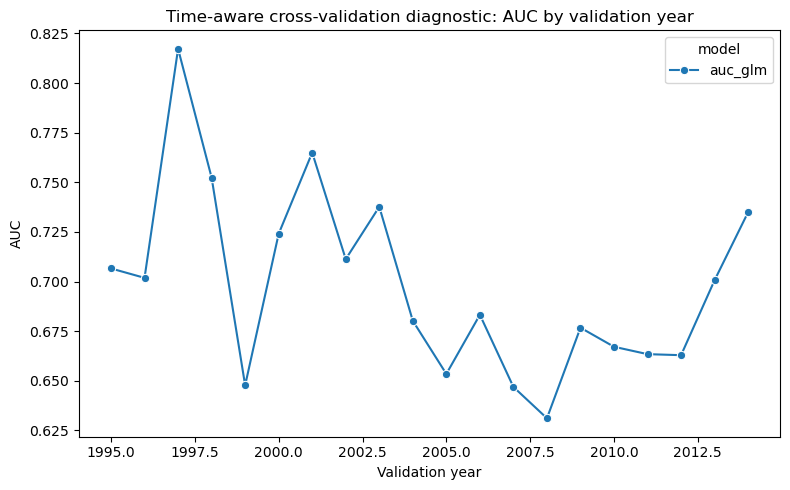

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.lineplot(
    data=fold_long,
    x="valid_year",
    y="auc",
    hue="model",
    marker="o"
)

plt.title("Time-aware cross-validation diagnostic: AUC by validation year")
plt.xlabel("Validation year")
plt.ylabel("AUC")

plt.tight_layout()
plt.show()